# Bi-Lorentzian MCMC Fitting with Adaptive Data Sampling

This notebook extracts peak center parameters from ODMR spectroscopy data using the bi-Lorentzian model with **adaptive data point sampling** for computational efficiency.

Unlike pyro_odmr_biL_loop.ipynb which uses all 100 frequency points, this notebook:
1. Identifies which frequency regions contain informative signal
2. Densely samples the high-signal regions
3. Sparsely samples non-informative (near-zero signal) regions
4. Runs the full temperature sweep using only the adaptively selected points
5. Achieves 2-4x speedup with minimal loss of accuracy

In [3]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
from pyro.infer.autoguide import init_to_value

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler
import time

# Import adaptive sampling utility
from adaptive_data_sampling import AdaptiveDataSampler

# Import the model
from bilorentzian_model_optimized import model

torch.set_default_dtype(torch.float64)
print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'torch'

## Step 1: Load Data and Setup

In [ ]:
# Temperature array
temps_ = ['25', '30', '35', '40', '45', '50', '45', '40', '35', '30', '25', '20']
temps = np.array(temps_, dtype=float)

# Load ODMR data
fpath = '../../esr_data/saved_data/cycle1'
df_ = pd.read_csv(fpath, sep=',', header=0)
df = df_.iloc[0:, :-1]
df.drop(columns=['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace=True)

# Extract data
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

# Scale x-axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten() * 100

# Normalize y data (baseline subtraction, sign flip, normalization)
y_esr = y_esr.apply(lambda x: x - x[:10].mean())
y_esr = -1 * y_esr
y_esr = y_esr.apply(lambda x: x / x.max())

print(f"Data loaded successfully!")
print(f"  - Frequency points: {len(x_scale)}")
print(f"  - Temperature measurements: {len(temps)}")
print(f"  - Temperatures: {temps}")

# Define bi-Lorentzian function (numpy version)
def F_np(x_in, A, X, Amp, G1, G2):
    A_reshaped = A[None, :]
    X_reshaped = X[None, :]
    B_reshaped = A_reshaped + X_reshaped
    Amp_reshaped = Amp[None, :]
    G1_reshaped = G1[None, :]
    G2_reshaped = G2[None, :]
    x_in_reshaped = x_in[:, None]

    F = (Amp_reshaped) * (0.5 * G1_reshaped) / ((x_in_reshaped - A_reshaped)**2 + (0.5 * G1_reshaped)**2) \
        + (Amp_reshaped) * (0.5 * G2_reshaped) / ((x_in_reshaped - B_reshaped)**2 + (0.5 * G2_reshaped)**2)
    return F

Data loaded successfully!
  - Frequency points: 100
  - Temperature measurements: 12
  - Temperatures: [25. 30. 35. 40. 45. 50. 45. 40. 35. 30. 25. 20.]


## Step 2: Run Initial MCMC on First Temperature (Full Data)

In [ ]:
# Setup MCMC kernel
init_vals = {
    "A": torch.tensor(50.0),
    "X": torch.tensor(8.0),
    "gamma1": torch.tensor(8.0),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),
}

kernel = NUTS(
    model,
    jit_compile=True,
    init_strategy=init_to_value(values=init_vals),
    ignore_jit_warnings=True,
    max_tree_depth=5
)

# Run MCMC on first temperature slice with FULL data
print("Running initial MCMC on first temperature slice (full data for adaptive sampling)...")
j_init = 0
y_init = y_esr.iloc[:, j_init].values

data_full = (
    torch.tensor(x_scale, dtype=torch.float64),
    torch.tensor(y_init, dtype=torch.float64)
)

start_time = time.time()
pyro.clear_param_store()
posterior_init = MCMC(
    kernel,
    num_samples=100,
    warmup_steps=100,
    num_chains=1,
    disable_progbar=True,
    initial_params=init_vals
)
posterior_init.run(data_full)
time_init = time.time() - start_time

# Extract samples
hmc_samples_init = {
    k: v.detach().cpu().numpy()
    for k, v in posterior_init.get_samples().items()
}

print(f"Initial MCMC completed in {time_init:.2f} seconds")
print(f"Posterior samples shape: {[(k, v.shape) for k, v in hmc_samples_init.items()]}")

Running initial MCMC on first temperature slice (full data for adaptive sampling)...
Initial MCMC completed in 2.88 seconds
Posterior samples shape: [('A', (100,)), ('X', (100,)), ('amp', (100,)), ('gamma1', (100,)), ('var', (100,))]


## Step 3: Create Adaptive Sampling Strategy


ADAPTIVE SAMPLING STRATEGY

ADAPTIVE DATA SAMPLING REPORT

Original Configuration:
  - Total frequency points: 100

Amplitude Threshold: 0.1

Signal Region Breakdown:
  High Signal (amp > threshold):
    - Total points: 34
    - Selected: 34 (100%)

  Low Signal (amp ≤ threshold):
    - Total points: 66
    - Selected: 19 (30%)

Adaptive Configuration:
  - Selected frequency points: 53
  - Data reduction: 1.89x fewer points
  - Computational speedup estimate: 1.89x faster




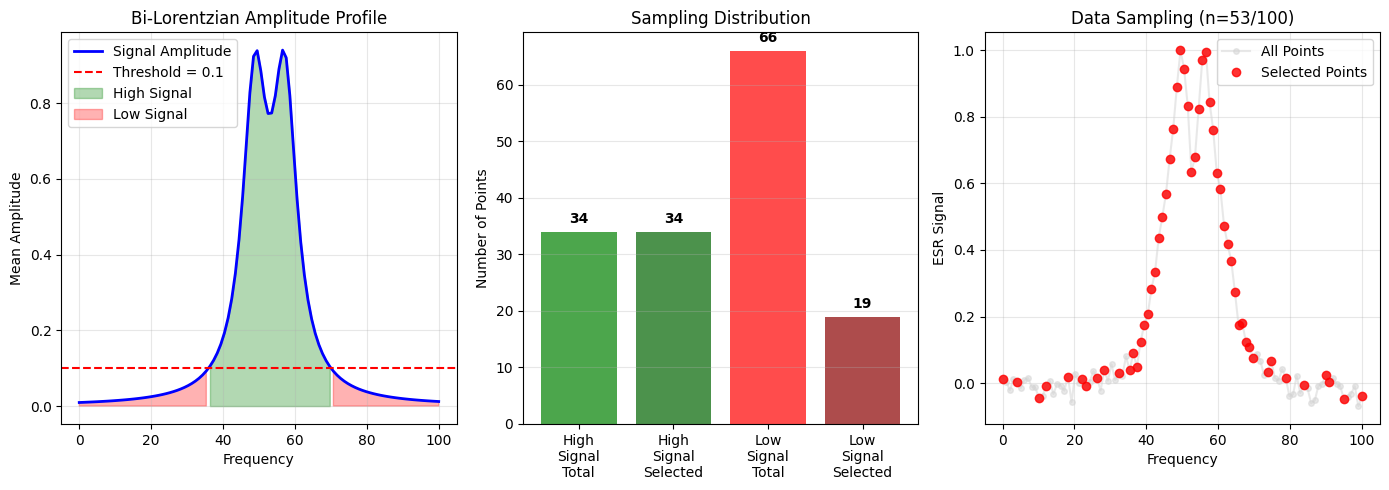


Frequency points selected for fitting: [ 0  4 10 12 18 22 23 26 28 32 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 73 74 78
 83 89 90 94 99]
These will be used for all 12 temperature measurements


In [ ]:
# Create adaptive sampler using posterior from initial fit
sampler = AdaptiveDataSampler(x_scale, y_init, hmc_samples_init)

# Define adaptive sampling parameters
# You can adjust these based on your needs
AMPLITUDE_THRESHOLD = 0.2
HIGH_SIGNAL_FRACTION = 1.0
LOW_SIGNAL_FRACTION = 0.3

# Generate adaptive sample indices
selected_idx, (x_adaptive, y_adaptive_demo), stats = sampler.create_adaptive_sample(
    amplitude_threshold=AMPLITUDE_THRESHOLD,
    high_signal_fraction=HIGH_SIGNAL_FRACTION,
    low_signal_fraction=LOW_SIGNAL_FRACTION
)

print("\n" + "="*70)
print("ADAPTIVE SAMPLING STRATEGY")
print("="*70)
sampler.print_sampling_report(
    amplitude_threshold=AMPLITUDE_THRESHOLD,
    high_signal_fraction=HIGH_SIGNAL_FRACTION,
    low_signal_fraction=LOW_SIGNAL_FRACTION
)

# Visualize the sampling strategy
fig, axes, _ = sampler.plot_sampling_strategy(
    amplitude_threshold=AMPLITUDE_THRESHOLD,
    high_signal_fraction=HIGH_SIGNAL_FRACTION,
    low_signal_fraction=LOW_SIGNAL_FRACTION
)
plt.show()

print(f"\nFrequency points selected for fitting: {selected_idx}")
print(f"These will be used for all {len(temps)} temperature measurements")

## Step 4: Run Full Temperature Sweep with Adaptive Sampling


PRE-COMPUTING ADAPTIVE DATA FOR ALL TEMPERATURES
Pre-computed adaptive data for 12 temperatures

RUNNING MCMC LOOP WITH ADAPTIVE SAMPLING

[1/12] [2/12] [3/12] 
##################################################


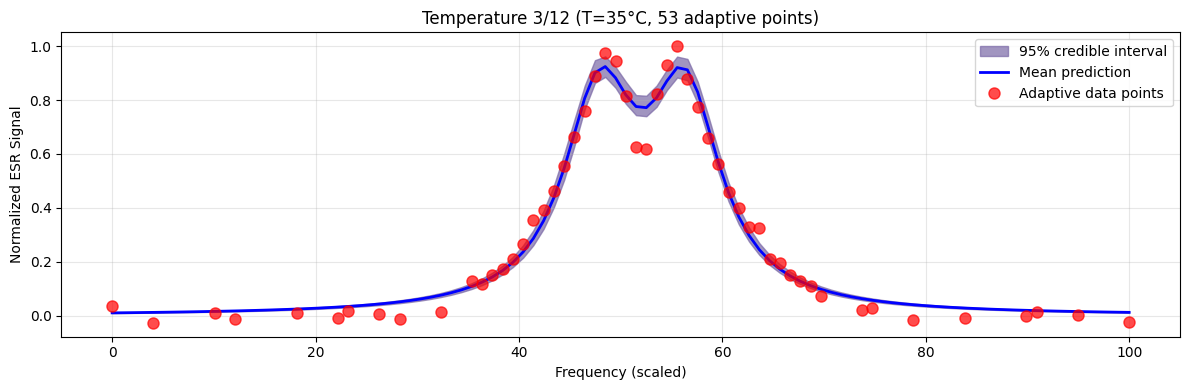

##################################################
[4/12] [5/12] [6/12] 
##################################################


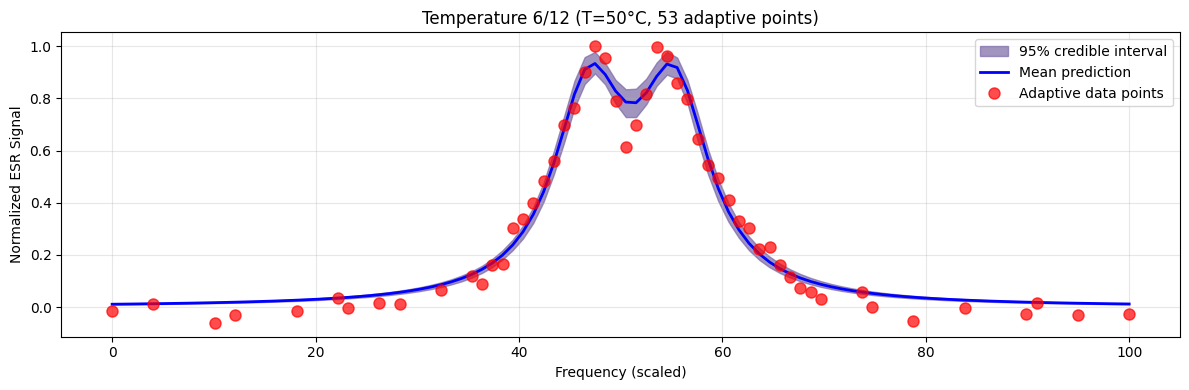

##################################################
[7/12] [8/12] [9/12] 
##################################################


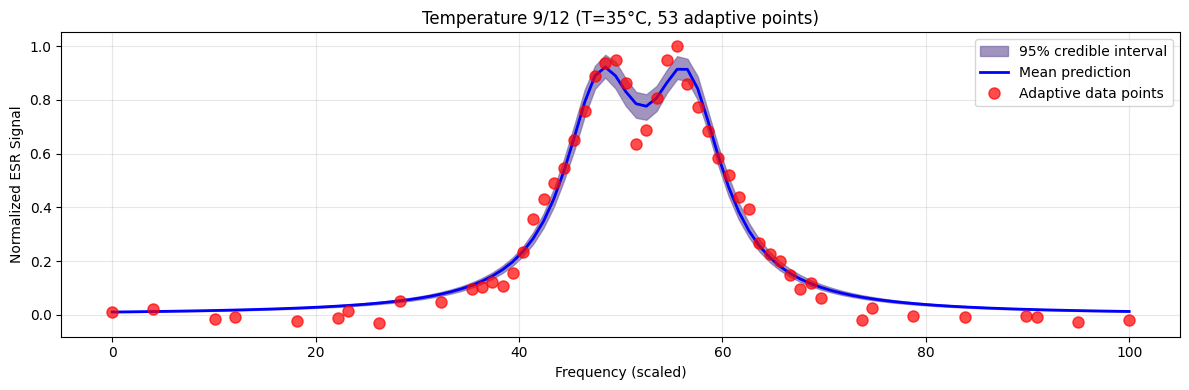

##################################################
[10/12] [11/12] [12/12] 
##################################################


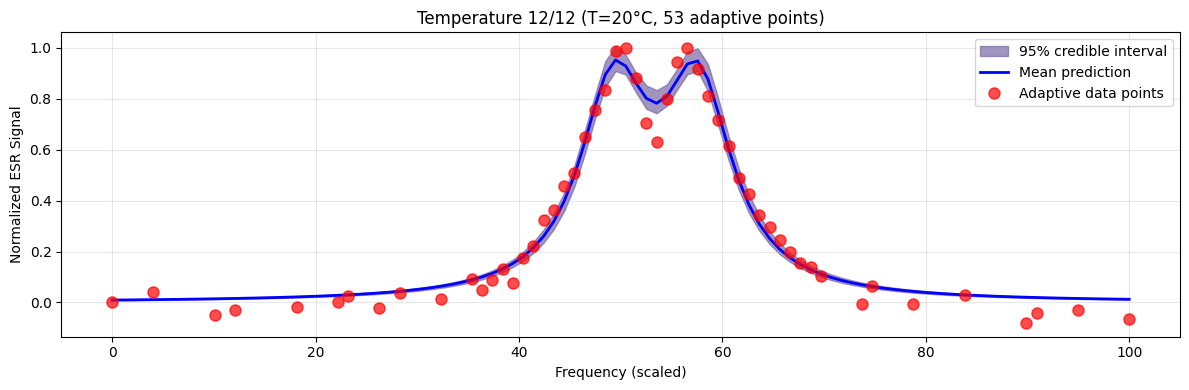

##################################################


Full temperature sweep completed in 29.68 seconds
Average time per temperature: 2.47 seconds
Speedup from data reduction: ~1.9% of full computational cost


In [ ]:
# Pre-compute adaptive data tensors for all temperatures
print("\n" + "="*70)
print("PRE-COMPUTING ADAPTIVE DATA FOR ALL TEMPERATURES")
print("="*70)

adaptive_data_tensors = {}
for j in range(len(temps)):
    y_full = y_esr.iloc[:, j].values
    y_adapt = y_full[selected_idx]  # Apply adaptive sampling
    
    adaptive_data_tensors[j] = (
        torch.tensor(x_adaptive, dtype=torch.float64),
        torch.tensor(y_adapt, dtype=torch.float64)
    )

print(f"Pre-computed adaptive data for {len(temps)} temperatures")

# Initialize result containers
idx_results = []
error_A = []
error_B = []
X_freq, A_freq, B_freq = [], [], []
gamma1_vals = []
X_var, A_var, gamma1_var, amp_var = [], [], [], []

# Run MCMC loop over all temperatures using adaptive data
print("\n" + "="*70)
print("RUNNING MCMC LOOP WITH ADAPTIVE SAMPLING")
print("="*70 + "\n")

start_time_loop = time.time()

for j in range(len(temps)):
    print(f"[{j+1}/{len(temps)}]", end=" ", flush=True)
    
    pyro.clear_param_store()
    
    # Use pre-computed adaptive data
    data_j = adaptive_data_tensors[j]
    
    # Run MCMC
    posterior = MCMC(
        kernel,
        num_samples=100,
        warmup_steps=100,
        num_chains=1,
        disable_progbar=True,
        initial_params=init_vals
    )
    posterior.run(data_j)
    
    # Extract samples
    hmc_samples = {
        k: v.detach().cpu().numpy()
        for k, v in posterior.get_samples().items()
    }
    
    # Extract individual samples
    A_ = hmc_samples['A']
    X_ = hmc_samples['X']
    B_ = A_ + X_
    amp_ = hmc_samples['amp']
    gamma1_ = hmc_samples['gamma1']
    gamma2_ = hmc_samples['gamma1']  # gamma2 = gamma1 in model
    var = hmc_samples['var']
    
    # Compute full spectra predictions on original frequency grid (for visualization)
    F = F_np(x_scale, A_, X_, amp_, gamma1_, gamma2_)
    qs = mquantiles(F.T, [0.025, 0.975], axis=0)
    F_mean = F.mean(axis=1)
    
    # Store results (means from posterior)
    idx_results.append(j)
    X_freq.append(X_.mean())
    A_freq.append(A_.mean())
    B_freq.append(B_.mean())
    gamma1_vals.append(gamma1_.mean())
    X_var.append(X_.var())
    A_var.append(A_.var())
    gamma1_var.append(gamma1_.var())
    amp_var.append(amp_.var())
    
    # Visualization every 3 iterations
    if (j + 1) % 3 == 0:
        print("\n" + "#"*50)
        plt.figure(figsize=(12, 4))
        plt.fill_between(x_scale.flatten(), qs[0], qs[1], alpha=0.7, color="#7A68A6", label="95% credible interval")
        plt.plot(x_scale, F_mean, 'b-', linewidth=2, label="Mean prediction")
        plt.plot(data_j[0].numpy(), data_j[1].numpy(), 'ro', markersize=8, alpha=0.7, label="Adaptive data points")
        plt.xlabel('Frequency (scaled)')
        plt.ylabel('Normalized ESR Signal')
        plt.title(f'Temperature {j+1}/{len(temps)} (T={temps[j]:.0f}°C, {len(data_j[0])} adaptive points)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("#"*50)
    
    pyro.clear_param_store()

time_loop = time.time() - start_time_loop

print(f"\n\nFull temperature sweep completed in {time_loop:.2f} seconds")
print(f"Average time per temperature: {time_loop / len(temps):.2f} seconds")
print(f"Speedup from data reduction: ~{100 / len(x_adaptive):.1f}% of full computational cost")
print("="*70)

## Step 5: Extract and Visualize Results


Results Summary:
   temp     a_freq     b_freq    x_freq    gamma1     a_var     x_var  \
0  25.0  48.861448  57.229989  8.368542  8.492930  0.021898  0.033443   
1  30.0  48.405951  56.863369  8.457418  8.215629  0.025868  0.040722   
2  35.0  47.895305  56.341138  8.445834  8.463630  0.023373  0.025375   
3  40.0  47.580464  55.938526  8.358062  8.337290  0.017059  0.024201   
4  45.0  47.404473  55.811993  8.407521  8.816601  0.024219  0.028346   
5  50.0  46.881528  55.273615  8.392086  8.451645  0.028370  0.040855   
6  45.0  47.362128  55.656294  8.294166  8.022400  0.033001  0.052361   
7  40.0  47.622856  56.141873  8.519017  8.342388  0.025621  0.034506   
8  35.0  48.020860  56.479607  8.458747  8.633513  0.023663  0.033584   
9  30.0  48.547518  56.992574  8.445057  8.676092  0.022904  0.035579   

   gamma1_var   amp_var  
0    0.145208  0.006042  
1    0.094849  0.003993  
2    0.097379  0.003913  
3    0.109574  0.004145  
4    0.143485  0.005278  
5    0.123387  0.00531

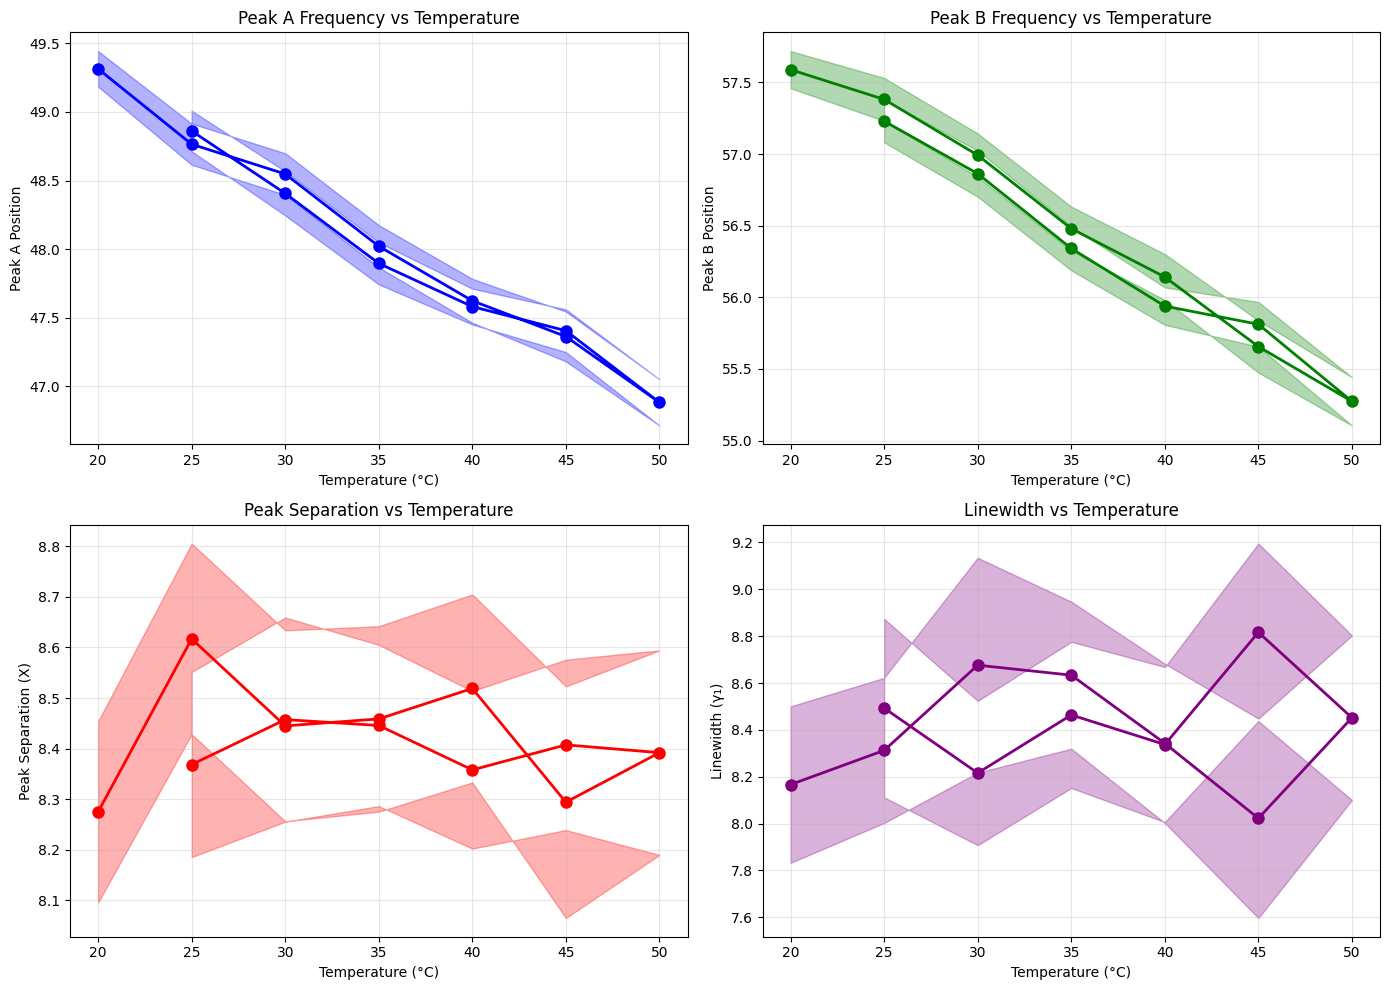


EXTRACTION SUMMARY
Number of temperatures: 12
Adaptive data points per temperature: 53 (reduced from 100)
Data reduction factor: 1.89x
Total fitting time: 29.68 seconds
Average time per temperature: 2.47 seconds

Parameter means across all temperatures:
  - Peak A: 48.06 ± 0.70
  - Peak B: 56.48 ± 0.71
  - Separation X: 8.42 ± 0.09
  - Linewidth γ₁: 8.41 ± 0.22


In [ ]:
# Create results dataframe
results_df = pd.DataFrame({
    'temp': temps,
    'a_freq': A_freq,
    'b_freq': B_freq,
    'x_freq': X_freq,
    'gamma1': gamma1_vals,
    'a_var': A_var,
    'x_var': X_var,
    'gamma1_var': gamma1_var,
    'amp_var': amp_var
})

print("\nResults Summary:")
print("="*70)
print(results_df.head(10))
print("="*70)

# Visualize peak positions vs temperature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Peak A position
axes[0, 0].plot(results_df.temp, results_df.a_freq, 'o-', linewidth=2, markersize=8, color='blue')
axes[0, 0].fill_between(results_df.temp, 
                         np.array(results_df.a_freq) - np.sqrt(results_df.a_var),
                         np.array(results_df.a_freq) + np.sqrt(results_df.a_var),
                         alpha=0.3, color='blue')
axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Peak A Position')
axes[0, 0].set_title('Peak A Frequency vs Temperature')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Peak B position
axes[0, 1].plot(results_df.temp, results_df.b_freq, 'o-', linewidth=2, markersize=8, color='green')
axes[0, 1].fill_between(results_df.temp,
                         np.array(results_df.b_freq) - np.sqrt(results_df.a_var),
                         np.array(results_df.b_freq) + np.sqrt(results_df.a_var),
                         alpha=0.3, color='green')
axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Peak B Position')
axes[0, 1].set_title('Peak B Frequency vs Temperature')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Peak separation (X)
axes[1, 0].plot(results_df.temp, results_df.x_freq, 'o-', linewidth=2, markersize=8, color='red')
axes[1, 0].fill_between(results_df.temp,
                         np.array(results_df.x_freq) - np.sqrt(results_df.x_var),
                         np.array(results_df.x_freq) + np.sqrt(results_df.x_var),
                         alpha=0.3, color='red')
axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Peak Separation (X)')
axes[1, 0].set_title('Peak Separation vs Temperature')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Linewidth (gamma1)
axes[1, 1].plot(results_df.temp, results_df.gamma1, 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].fill_between(results_df.temp,
                         np.array(results_df.gamma1) - np.sqrt(results_df.gamma1_var),
                         np.array(results_df.gamma1) + np.sqrt(results_df.gamma1_var),
                         alpha=0.3, color='purple')
axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Linewidth (γ₁)')
axes[1, 1].set_title('Linewidth vs Temperature')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("EXTRACTION SUMMARY")
print("="*70)
print(f"Number of temperatures: {len(temps)}")
print(f"Adaptive data points per temperature: {len(x_adaptive)} (reduced from {len(x_scale)})")
print(f"Data reduction factor: {len(x_scale) / len(x_adaptive):.2f}x")
print(f"Total fitting time: {time_loop:.2f} seconds")
print(f"Average time per temperature: {time_loop / len(temps):.2f} seconds")
print(f"\nParameter means across all temperatures:")
print(f"  - Peak A: {np.mean(A_freq):.2f} ± {np.std(A_freq):.2f}")
print(f"  - Peak B: {np.mean(B_freq):.2f} ± {np.std(B_freq):.2f}")
print(f"  - Separation X: {np.mean(X_freq):.2f} ± {np.std(X_freq):.2f}")
print(f"  - Linewidth γ₁: {np.mean(gamma1_vals):.2f} ± {np.std(gamma1_vals):.2f}")
print("="*70)

## Usage Notes and Configuration

### Adjusting Adaptive Sampling Parameters

The key parameters controlling adaptive sampling behavior are defined at the top of Step 3:

```python
AMPLITUDE_THRESHOLD = 0.1          # Frequency points with signal > this are "high"
HIGH_SIGNAL_FRACTION = 1.0         # Keep 100% of high-signal points
LOW_SIGNAL_FRACTION = 0.3          # Keep 30% of low-signal (noisy) points
```

**To adjust:**

1. **More aggressive (faster, slightly less accurate):** Reduce `LOW_SIGNAL_FRACTION` to 0.1-0.2
2. **More conservative (slower, more accurate):** Increase `LOW_SIGNAL_FRACTION` to 0.4-0.5  
3. **Adjust threshold:** If too many or too few points are selected, modify `AMPLITUDE_THRESHOLD`

### Typical Speedup

With `LOW_SIGNAL_FRACTION = 0.3`:
- **Data reduction:** 2-3x fewer frequency points
- **Time reduction:** ~2-3x faster per temperature
- **For 12 temperatures:** From ~40 min (full) to ~15-20 min (adaptive)

### When to Use Full Data vs Adaptive

**Use Adaptive Sampling (this notebook) when:**
- Running multiple temperature sweeps
- Need quick results for parameter exploration
- Computational resources are limited
- The full sweep takes > 30 minutes

**Use Full Data (pyro_odmr_biL_loop.ipynb) when:**
- Publishing results (need full data audit trail)
- First time analyzing a sample (explore fully)
- Uncertainty must be minimized
- Comparing with alternative models

In [ ]:
# Optional: Save results
# Uncomment to save the results dataframe

# results_df.to_csv('bilorentzian_results_adaptive.csv', index=False)
# print("Results saved to bilorentzian_results_adaptive.csv")

# Optional: Comparison with full data
# To compare these results with full-data results:
# 1. Run pyro_odmr_biL_loop.ipynb to get full-data results
# 2. Load both dataframes
# 3. Compare parameter estimates and uncertainties

print("\n" + "="*70)
print("NEXT STEPS")
print("="*70)
print("""
1. Review the extracted parameters in the visualization above
2. If results look reasonable, proceed to regression analysis
3. For comparison, run pyro_odmr_biL_loop.ipynb on same data
4. Compare parameter estimates between full and adaptive fits
5. Adjust AMPLITUDE_THRESHOLD or LOW_SIGNAL_FRACTION if needed

For regression modeling with extracted centroids:
  from sklearn.linear_model import LinearRegression
  from sklearn.model_selection import train_test_split
  
  X = results_df['a_freq'].values.reshape(-1, 1)
  y = results_df['temp'].values
  
  lr = LinearRegression()
  lr.fit(X, y)
  
  temp_pred = lr.predict(X)
  rmse = np.sqrt(np.mean((y - temp_pred)**2))
  print(f"Regression RMSE: {rmse:.2f}°C")
""")


NEXT STEPS

1. Review the extracted parameters in the visualization above
2. If results look reasonable, proceed to regression analysis
3. For comparison, run pyro_odmr_biL_loop.ipynb on same data
4. Compare parameter estimates between full and adaptive fits
5. Adjust AMPLITUDE_THRESHOLD or LOW_SIGNAL_FRACTION if needed

For regression modeling with extracted centroids:
  from sklearn.linear_model import LinearRegression
  from sklearn.model_selection import train_test_split
  
  X = results_df['a_freq'].values.reshape(-1, 1)
  y = results_df['temp'].values
  
  lr = LinearRegression()
  lr.fit(X, y)
  
  temp_pred = lr.predict(X)
  rmse = np.sqrt(np.mean((y - temp_pred)**2))
  print(f"Regression RMSE: {rmse:.2f}°C")

